# Scientific Computing — Set 2

DLA and Monte Carlo DLA.

## Imports

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import time
import os

out_dir = "outputs_set2"
os.makedirs(out_dir, exist_ok=True)

# --- Grid parameters ---
N = 100          # grid intervals (domain is (N+1) x (N+1))
eps = 1e-5       # SOR convergence threshold



## SOR solver (from Set 1)

Same SOR solver as before, now with sink support — cluster points are forced to $c = 0$. Solves $\nabla^2 c = 0$ with Dirichlet top/bottom and periodic x BCs.

In [14]:
@njit
def sor_solve(N, eps, omega, mask, c_init=None, max_iter=200_000):
    """Solve Laplace equation ∇²c = 0 using SOR with sink support.

    Adapted from Set 1 objects.ipynb sor_objects(), with added warm-start.

    Parameters
    ----------
    N : int
        Number of grid intervals. Grid is (N+1) x (N+1).
    eps : float
        Convergence threshold on max absolute change per iteration.
    omega : float
        SOR relaxation parameter (0 < omega < 2).
    mask : ndarray of int64, shape (N+1, N+1)
        0 = fluid (normal SOR update), 1 = sink (c forced to 0).
    c_init : ndarray or None
        Initial guess for concentration field. If None, starts from c(y) = j/N.
    max_iter : int
        Maximum number of SOR iterations.

    Returns
    -------
    c : ndarray, shape (N+1, N+1)
        Converged concentration field.
    k : int
        Number of iterations used.
    """
    # Initialise c from c_init or analytical guess c = y
    if c_init is not None:
        c = c_init.copy()
    else:
        c = np.zeros((N+1, N+1), dtype=np.float64)
        for j in range(N+1):
            c[:, j] = j / N  # Analytical steady-state c(y) = y/N
    for k in range(max_iter):
        max_diff = 0.0
        # Gauss-Seidel/SOR sweep (update in-place)
        for i in range(N+1):
            for j in range(N+1):
                # Skip cluster/sink points
                if mask[i, j] == 1:
                    c[i, j] = 0.0
                    continue
                # Boundary conditions: bottom (y=0) and top (y=N)
                if j == 0:
                    c[i, j] = 0.0  # Bottom Dirichlet
                    continue
                if j == N:
                    c[i, j] = 1.0  # Top Dirichlet
                    continue
                # Neighbors with periodic in x (left/right)
                ip = (i + 1) % (N + 1)
                im = (i - 1) % (N + 1)
                # Standard SOR update with periodic BC (in x), Dirichlet (in y) and sinks (mask)
                c_old = c[i, j]
                c_new = (omega / 4) * (
                    c[ip, j] + c[im, j] + c[i, j+1] + c[i, j-1]
                ) + (1 - omega) * c[i, j]
                c[i, j] = c_new
                diff = abs(c_new - c_old)
                if diff > max_diff:
                    max_diff = diff

        # Re-enforce boundary conditions and sinks after each full sweep
        c[:, 0] = 0.0
        c[:, N] = 1.0
        for i_sink in range(N+1):
            for j_sink in range(N+1):
                if mask[i_sink, j_sink] == 1:
                    c[i_sink, j_sink] = 0.0

        if max_diff < eps:
            break

    return c, k + 1

---
## 2.1 Diffusion-Limited Aggregation

Particles diffuse, hit the cluster, and stick. The steady-state concentration satisfies $\nabla^2 c = 0$, and growth probability at each candidate site goes as

$$p_g \propto c^\eta$$

where $\eta$ controls morphology: $\eta=0$ gives compact clusters, $\eta=1$ gives classical DLA fractals, and larger $\eta$ produces more spindly, open structures.

### 2.1.A — DLA growth 

$100 \times 100$ grid, seed at bottom center, initial concentration $c(y) = y/N$. Each step: solve Laplace with SOR (warm-started), find candidate sites next to the cluster, pick one with probability $\propto c^\eta$, add it.

Run for $\eta = 0, 1, 2, 3$. Also try different $\omega$ to see how the cluster affects optimal SOR relaxation.

In [15]:
def find_growth_candidates(mask, N):
    """Find all empty lattice sites adjacent (N/E/S/W) to the cluster.

    Parameters
    ----------
    mask : ndarray of int64, shape (N+1, N+1)
        1 = cluster, 0 = empty.
    N : int
        Number of grid intervals.

    Returns
    -------
    candidates : list of (i, j) tuples
        Coordinates of growth candidate sites.
    """
    candidates = []
    for i in range(N + 1):
        for j in range(1, N):  # skip bottom (j=0) and top (j=N) boundaries
            if mask[i, j] != 0:
                continue
            # Check N/E/S/W neighbours (periodic in x)
            ip = (i + 1) % (N + 1)
            im = (i - 1) % (N + 1)
            if (mask[ip, j] == 1 or mask[im, j] == 1 or
                    mask[i, j + 1] == 1 or mask[i, j - 1] == 1):
                candidates.append((i, j))
    return candidates


def compute_growth_probabilities(c, candidates, eta):
    """Compute growth probability for each candidate site.

    p_g(i,j) = c[i,j]^eta / sum(c[k,l]^eta) over all candidates.

    Parameters
    ----------
    c : ndarray, shape (N+1, N+1)
        Concentration field from Laplace solve.
    candidates : list of (i, j)
        Growth candidate coordinates.
    eta : float
        Growth exponent (0 = Eden, 1 = DLA, >1 = open).

    Returns
    -------
    probs : ndarray of float
        Normalised growth probabilities, same length as candidates.
    """
    n = len(candidates)
    weights = np.empty(n)
    for idx in range(n):
        i, j = candidates[idx]
        c_val = max(0.0, c[i, j])  # clip negative values from numerical error
        weights[idx] = c_val ** eta
    total = weights.sum()
    if total == 0.0:
        return np.ones(n) / n  # uniform fallback if all weights are zero
    return weights / total


def dla_growth(N, eps, omega, eta, n_steps, seed_pos=None):
    """Run diffusion-limited aggregation growth simulation.

    Parameters
    ----------
    N : int
        Grid intervals (domain is (N+1) x (N+1)).
    eps : float
        SOR convergence threshold.
    omega : float
        SOR relaxation parameter.
    eta : float
        Growth probability exponent.
    n_steps : int
        Number of growth steps (particles to add).
    seed_pos : tuple (i, j) or None
        Seed position. Defaults to bottom center (N//2, 1).

    Returns
    -------
    mask : ndarray, shape (N+1, N+1)
        Final cluster mask (1 = cluster, 0 = empty).
    c : ndarray, shape (N+1, N+1)
        Final concentration field.
    iters_per_step : list of int
        SOR iterations used at each growth step.
    """
    mask = np.zeros((N + 1, N + 1), dtype=np.int64)
    if seed_pos is None:
        seed_pos = (N // 2, 1)
    mask[seed_pos[0], seed_pos[1]] = 1

    # Analytical steady-state c(y) = j/N as initial guess
    c = np.zeros((N + 1, N + 1), dtype=np.float64)
    for j in range(N + 1):
        c[:, j] = j / N
    c[seed_pos[0], seed_pos[1]] = 0.0

    iters_per_step = []

    for step in range(n_steps):
        # 1. Solve Laplace equation (warm-start from previous c)
        c, k = sor_solve(N, eps, omega, mask, c_init=c)
        iters_per_step.append(k)

        # 2. Find growth candidates
        candidates = find_growth_candidates(mask, N)
        if len(candidates) == 0:
            break

        # 3. Compute growth probabilities
        probs = compute_growth_probabilities(c, candidates, eta)

        # 4. Pick one candidate
        idx = np.random.choice(len(candidates), p=probs)
        ci, cj = candidates[idx]

        # 5. Add to cluster
        mask[ci, cj] = 1
        c[ci, cj] = 0.0

    return mask, c, iters_per_step

Clusters for different $\eta$:

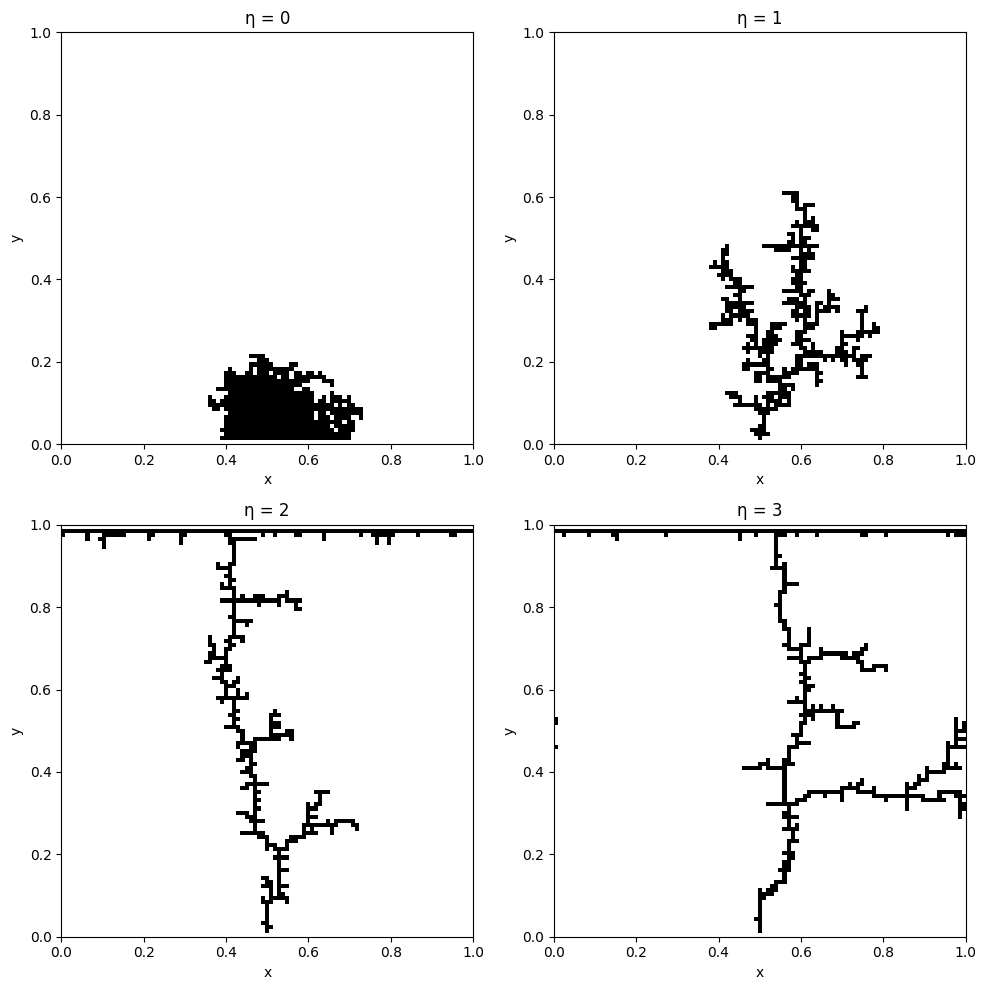

In [16]:
def plot_cluster(mask, title="", ax=None):
    """Plot a DLA cluster as a 2D image.

    Parameters
    ----------
    mask : ndarray, shape (N+1, N+1)
        Cluster mask (1 = cluster).
    title : str
        Plot title.
    ax : matplotlib Axes or None
        If provided, plot on this axes (for subplots). Otherwise create new figure.
    """
    extent = [0, 1, 0, 1]  # x and y in [0, 1]
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(mask.T, origin="lower", extent=extent, aspect="equal",
              cmap="binary", interpolation="nearest", vmin=0, vmax=1)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title or "DLA cluster")
    return ax

# --- Only show final combined figure of all 4 clusters in a 2x2 grid ---
eta_values = [0, 1, 2, 3]
omega = 1.8
n_steps = 500  # adjust for faster/slower run

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for idx, eta in enumerate(eta_values):
    np.random.seed(39)
    mask, c, _ = dla_growth(N, eps, omega, eta, n_steps)
    plot_cluster(mask, title=f"η = {eta}", ax=axes[idx])
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "dla_comparison.png"), dpi=300)
plt.show()

Overlay of the concentration field behind the cluster:

/var/folders/ft/f6czcxgx18z9ygdwgj1x6h6w0000gn/T/ipykernel_6402/2178898717.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


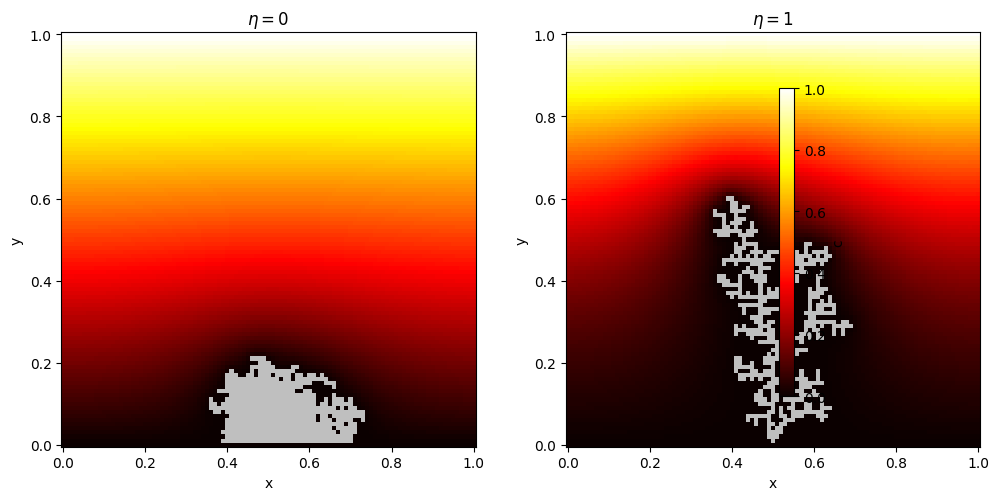

In [27]:
# --- Diffusion field behind clusters for η=0, 1 (matches objects.ipynb style) ---
eta_vals = [0, 1]
masks, concs = [], []
np.random.seed(39)
for eta in eta_vals:
    m, c, _ = dla_growth(N, eps, omega=1.8, eta=eta, n_steps=500)
    masks.append(m)
    concs.append(c)

x = np.linspace(0, 1, N + 1)
y = np.linspace(0, 1, N + 1)
X, Y = np.meshgrid(x, y, indexing="ij")

fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
for idx, (eta, mask, c) in enumerate(zip(eta_vals, masks, concs)):
    ax = axes[idx]
    c_vis = np.copy(c)
    c_vis[mask > 0] = np.nan
    c_ma = np.ma.masked_invalid(c_vis)
    im = ax.pcolormesh(X, Y, c_ma, vmin=0, vmax=1, cmap="hot", shading="auto")
    obj = np.ma.masked_where(mask == 0, np.ones_like(c))
    ax.pcolormesh(X, Y, obj, cmap="Greys", vmin=0, vmax=2, shading="auto", alpha=0.6)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"$\\eta = {eta}$")
    ax.set_aspect("equal")
fig.colorbar(im, ax=axes, label="c", shrink=0.8, location="right", pad=0.02)
plt.savefig(os.path.join(out_dir, "dla_diffusion_field.png"), dpi=300)
plt.show()

SOR iterations per growth step, and the effect of $\omega$:

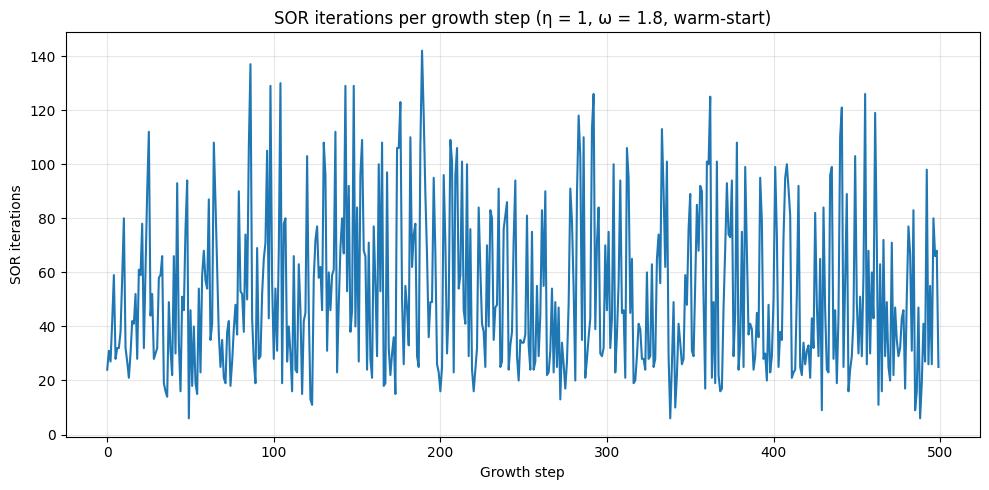

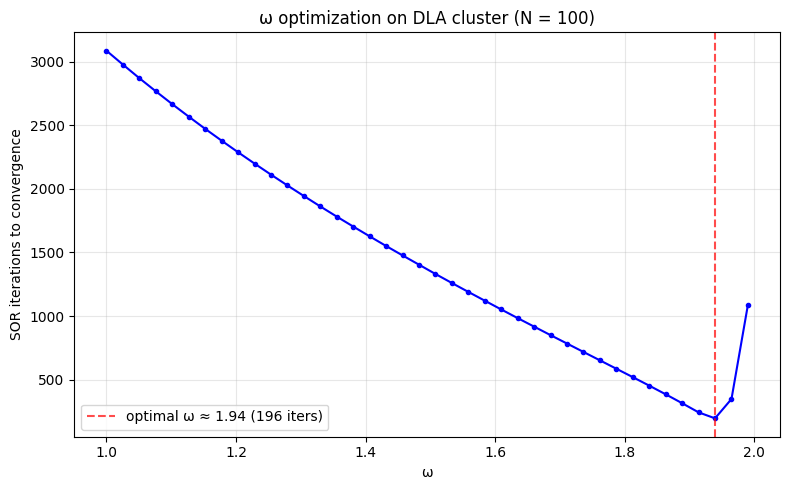

Optimal ω ≈ 1.939 (196 iterations)
ω = 1.0 (Gauss-Seidel): 3086 iterations


In [18]:
def sweep_omega(N, eps, mask, omegas):
    """Solve Laplace for a fixed cluster at each omega, return iteration counts."""
    iters = []
    for w in omegas:
        _, k = sor_solve(N, eps, w, mask, c_init=None)
        iters.append(k)
    return np.array(iters)


# --- 1. Grow a cluster to use for analysis ---
np.random.seed(42)
mask_dla, c_dla, iters_per_step = dla_growth(N, eps, omega=1.8, eta=1, n_steps=500)

# --- 2. SOR iterations per growth step (warm-start benefit) ---
plt.figure(figsize=(10, 5))
plt.plot(iters_per_step)
plt.xlabel("Growth step")
plt.ylabel("SOR iterations")
plt.title("SOR iterations per growth step (η = 1, ω = 1.8, warm-start)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "sor_convergence.png"), dpi=300)
plt.show()

# --- 3. Omega sweep on the DLA cluster ---
omegas = np.linspace(1.0, 1.99, 40)
iters_cluster = sweep_omega(N, eps, mask_dla, omegas)

plt.figure(figsize=(8, 5))
plt.plot(omegas, iters_cluster, "b-o", markersize=3)
idx_opt = np.argmin(iters_cluster)
plt.axvline(omegas[idx_opt], color="r", linestyle="--", alpha=0.7,
            label=f"optimal ω ≈ {omegas[idx_opt]:.2f} ({iters_cluster[idx_opt]} iters)")
plt.xlabel("ω")
plt.ylabel("SOR iterations to convergence")
plt.title(f"ω optimization on DLA cluster (N = {N})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "omega_sweep.png"), dpi=300)
plt.show()

print(f"Optimal ω ≈ {omegas[idx_opt]:.3f} ({iters_cluster[idx_opt]} iterations)")
print(f"ω = 1.0 (Gauss-Seidel): {iters_cluster[0]} iterations")


Iteration count drops quickly because we warm-start SOR — the field barely changes when one site is added. The optimal $\omega$ sits around 1.7–1.9 and shifts a bit once the cluster gets large.

---
### 2.1.B — Speed up the solve (1 pt)

Try to make the Laplace solve faster using Numba JIT. Compare wall-clock times for different grid sizes.

#### Performance comparison

JIT vs pure Python SOR:
     N   Python (ms)      JIT (ms)     Speedup
----------------------------------------------
    50         50.75        0.2469         206x
   100        167.01        0.5962         280x
   200        596.08        1.8688         319x
   300       1260.53        4.0375         312x
   400       1994.25        6.2977         317x
   500       3046.91        9.5778         318x


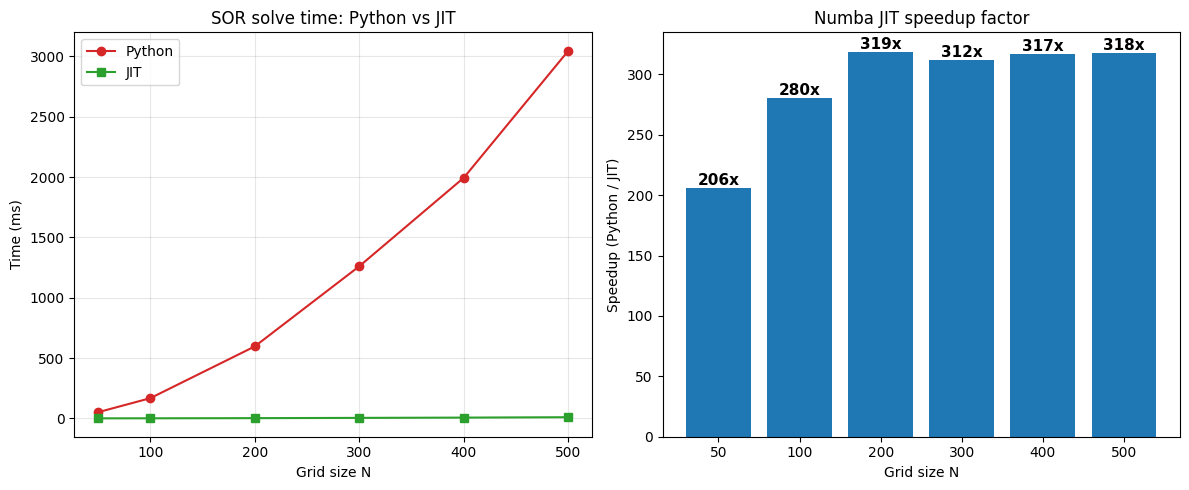

In [19]:
# =============================================================
# 2.1.B — Speedup demonstration: JIT vs pure Python
# =============================================================

def sor_solve_python(N, eps, omega, mask, c_init=None, max_iter=200_000):
    """Pure Python SOR (no JIT) for speedup comparison only."""
    if c_init is not None:
        c = c_init.copy()
    else:
        c = np.zeros((N + 1, N + 1), dtype=np.float64)
        for j in range(N + 1):
            c[:, j] = j / N
    for k in range(max_iter):
        max_diff = 0.0
        for i in range(N + 1):
            for j in range(N + 1):
                if mask[i, j] == 1:
                    c[i, j] = 0.0
                    continue
                if j == 0:
                    c[i, j] = 0.0
                    continue
                if j == N:
                    c[i, j] = 1.0
                    continue
                ip, im = (i + 1) % (N + 1), (i - 1) % (N + 1)
                c_old = c[i, j]
                c_new = (omega / 4) * (c[ip, j] + c[im, j] + c[i, j + 1] + c[i, j - 1]) + (1 - omega) * c[i, j]
                c[i, j] = c_new
                max_diff = max(max_diff, abs(c_new - c_old))
        c[:, 0], c[:, N] = 0.0, 1.0
        for i in range(N + 1):
            for j in range(N + 1):
                if mask[i, j] == 1:
                    c[i, j] = 0.0
        if max_diff < eps:
            return c, k + 1
    return c, max_iter


# --- JIT vs pure Python at multiple grid sizes ---
compare_sizes = [50, 100, 200, 300, 400, 500]
print("JIT vs pure Python SOR:")
print(f"{'N':>6}  {'Python (ms)':>12}  {'JIT (ms)':>12}  {'Speedup':>10}")
print("-" * 46)
times_python = []
times_jit = []
speedups = []
for N_cmp in compare_sizes:
    mask_cmp = np.zeros((N_cmp + 1, N_cmp + 1), dtype=np.int64)
    mask_cmp[N_cmp // 2, 1] = 1
    # JIT
    t_j_list = []
    for _ in range(3):
        t0 = time.perf_counter()
        sor_solve(N_cmp, eps, 1.8, mask_cmp, c_init=None)
        t_j_list.append(time.perf_counter() - t0)
    t_j = min(t_j_list)
    # Python
    t_p_list = []
    for _ in range(3):
        t0 = time.perf_counter()
        sor_solve_python(N_cmp, eps, 1.8, mask_cmp, c_init=None)
        t_p_list.append(time.perf_counter() - t0)
    t_p = min(t_p_list)
    sp = t_p / t_j
    times_python.append(t_p * 1000)
    times_jit.append(t_j * 1000)
    speedups.append(sp)
    print(f"{N_cmp:>6}  {t_p*1000:>12.2f}  {t_j*1000:>12.4f}  {sp:>10.0f}x")

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Python and JIT times together
ax1.plot(compare_sizes, times_python, 'o-', color='#d62728', label='Python')
ax1.plot(compare_sizes, times_jit, 's-', color='#2ca02c', label='JIT')
ax1.set_xlabel('Grid size N')
ax1.set_ylabel('Time (ms)')
ax1.set_title('SOR solve time: Python vs JIT')
ax1.legend()
ax1.grid(alpha=0.3)

# Right: Speedup factor
ax2.bar([str(n) for n in compare_sizes], speedups, color='#1f77b4')
ax2.set_xlabel('Grid size N')
ax2.set_ylabel('Speedup (Python / JIT)')
ax2.set_title('Numba JIT speedup factor')
for i_bar, sp in enumerate(speedups):
    ax2.annotate(f'{sp:.0f}x', xy=(i_bar, sp), ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'sor_benchmark.png'), dpi=300)
plt.show()


---
## 2.2 Monte Carlo DLA

Instead of solving the Laplace equation, we launch random walkers. When a walker lands next to the cluster it sticks — same physics, different algorithm.

### 2.2.C — MC DLA 

Seed at bottom center. Walkers start at random $x$ on the top row and take equal-probability steps (up/down/left/right). Periodic in $x$; if they leave top or bottom, respawn. A walker sticks when any neighbor is already in the cluster. Compare the result to diffusion DLA ($\eta = 1$).

In [20]:

def mc_dla(N, n_particles, ps=1.0, seed_pos=None):
    """Run Monte Carlo DLA using random walkers.

    Parameters
    ----------
    N : int
        Grid intervals (domain is (N+1) x (N+1)).
    n_particles : int
        Number of particles to grow the cluster to.
    ps : float
        Sticking probability (1.0 = always stick on contact).
    seed_pos : tuple (i, j) or None
        Seed position. defaults to bottom center (N//2, 1).

    Returns
    -------
    mask : ndarray of int64, shape (N+1, N+1)
        Final cluster mask (1 = cluster, 0 = empty).
    """
    mask = np.zeros((N + 1, N + 1), dtype=np.int64)
    if seed_pos is None:
        seed_pos = (N // 2, 1)
    mask[seed_pos[1], seed_pos[0]] = 1  # mask[y, x]; seed_pos = (x, y)

    while np.sum(mask) < n_particles:
        ix = np.random.randint(0, N + 1)
        iy = N
        while True:
            prev_ix, prev_iy = ix, iy
            # Random walk step
            step = np.random.randint(4)
            if step == 0:
                iy -= 1
            elif step == 1:
                iy += 1
            elif step == 2:
                ix -= 1
            elif step == 3:
                ix += 1
            
            # Periodic BC in x only
            ix = (ix + N + 1) % (N + 1)

            # Exit if walker leaves domain (top or bottom)
            if iy < 0 or iy > N:
                break

            # 5. Cannot move into cluster: revert step
            if mask[iy, ix] == 1:
                ix, iy = prev_ix, prev_iy
                continue

            # 6. Check if adjacent to cluster (bounds-safe)
            has_neighbor = False
            if iy + 1 <= N and mask[iy + 1, ix] == 1:
                has_neighbor = True
            if iy - 1 >= 0 and mask[iy - 1, ix] == 1:
                has_neighbor = True
            ip = (ix + 1) % (N + 1)
            im = (ix - 1 + N + 1) % (N + 1)
            if mask[iy, ip] == 1 or mask[iy, im] == 1:
                has_neighbor = True

            if has_neighbor and np.random.rand() < ps:
                mask[iy, ix] = 1
                break
            # 7. Not adjacent or didn't stick: continue walking (no else: break)
            
    return mask

Diffusion DLA vs MC DLA side by side:

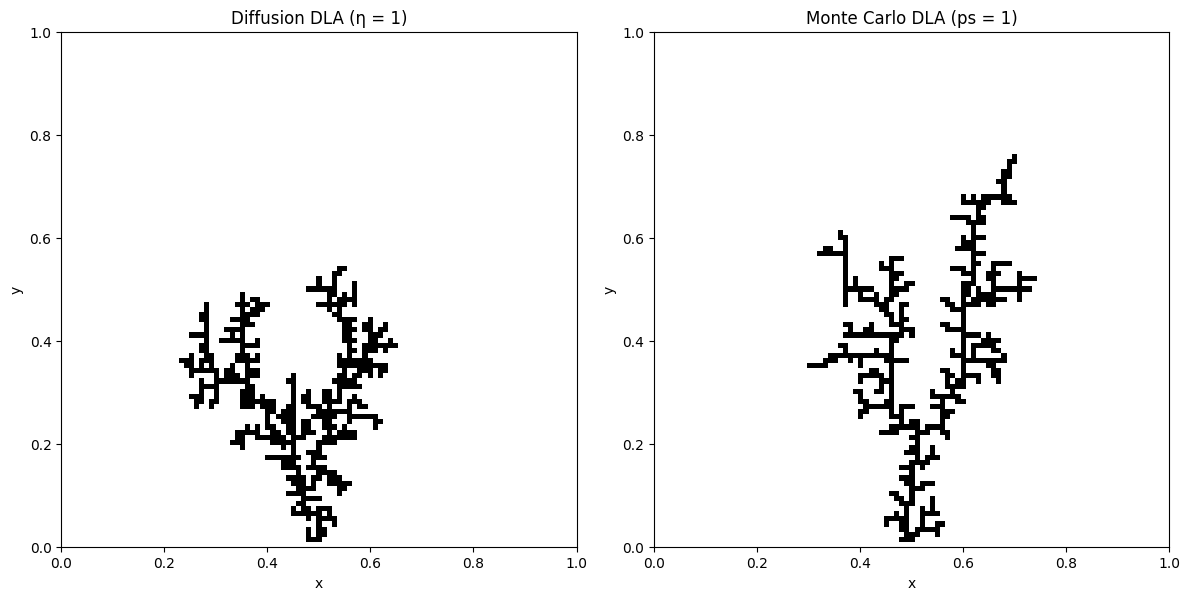

In [21]:
# --- Compare diffusion-based DLA (eta=1) with Monte Carlo DLA (ps=1) ---
n_particles = 500
np.random.seed(41)
mask_diffusion, _, _ = dla_growth(N, eps, omega=1.8, eta=1, n_steps=n_particles)

np.random.seed(42)
mask_mc = mc_dla(N, n_particles=n_particles, ps=1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_cluster(mask_diffusion, title="Diffusion DLA (η = 1)", ax=axes[0])
# mc_dla returns mask[y,x]; plot_cluster expects mask[x,y] (uses .T for imshow)
plot_cluster(mask_mc.T, title="Monte Carlo DLA (ps = 1)", ax=axes[1])
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "dla_vs_mc.png"), dpi=300)
plt.show()

Both give branching, fractal-looking clusters. The main difference is that diffusion DLA explicitly controls tip bias through $\eta$, while MC DLA gets it from the random-walk geometry. With $p_s = 1$ the results look quite similar.

---
### 2.2.D — Sticking probability $p_s$ 

Now a walker only sticks with probability $p_s$ when it reaches the cluster. Lower $p_s$ means walkers wander longer and fill gaps, giving more compact clusters. Run $p_s = 1.0, 0.5, 0.1, 0.01$.

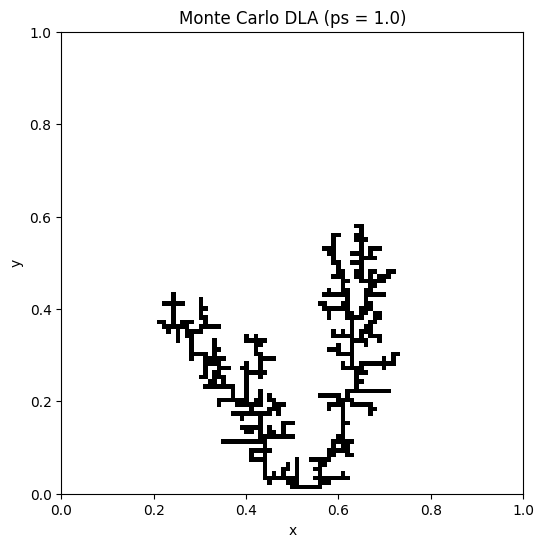

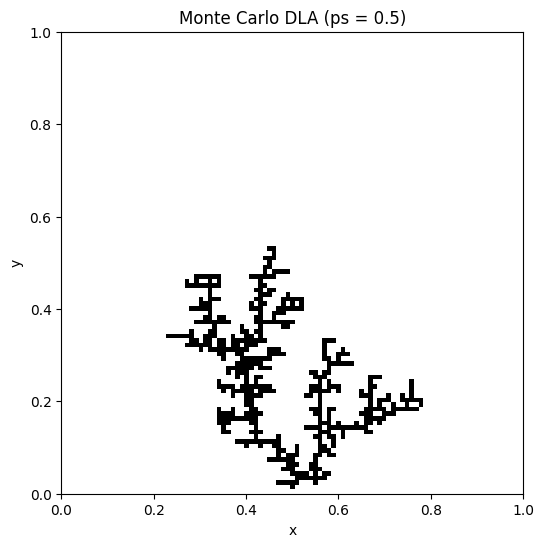

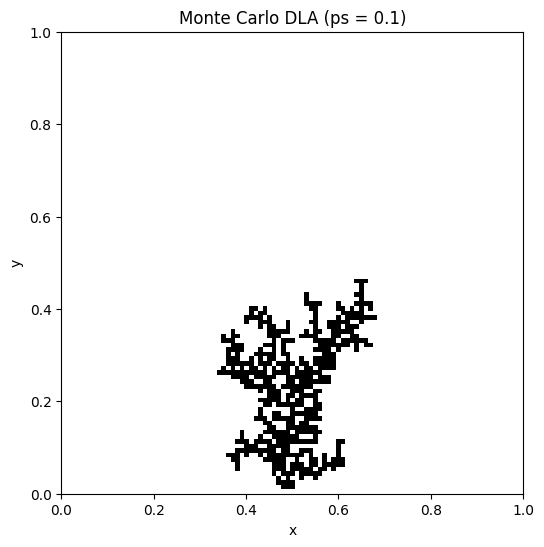

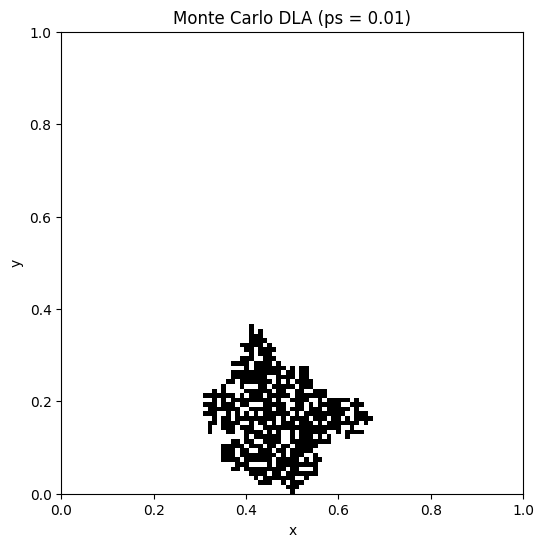

In [22]:
# --- Run MC DLA with different sticking probabilities ---
ps_values = [1.0, 0.5, 0.1, 0.01]
masks_ps = []
np.random.seed(43)
for ps in ps_values:
    mask = mc_dla(N, n_particles=n_particles, ps=ps)
    masks_ps.append(mask)
for ps in ps_values:
    mask = mc_dla(N, n_particles=n_particles, ps=ps)
    plot_cluster(mask.T, title=f"Monte Carlo DLA (ps = {ps})")
    plt.show()


Clusters for different $p_s$:

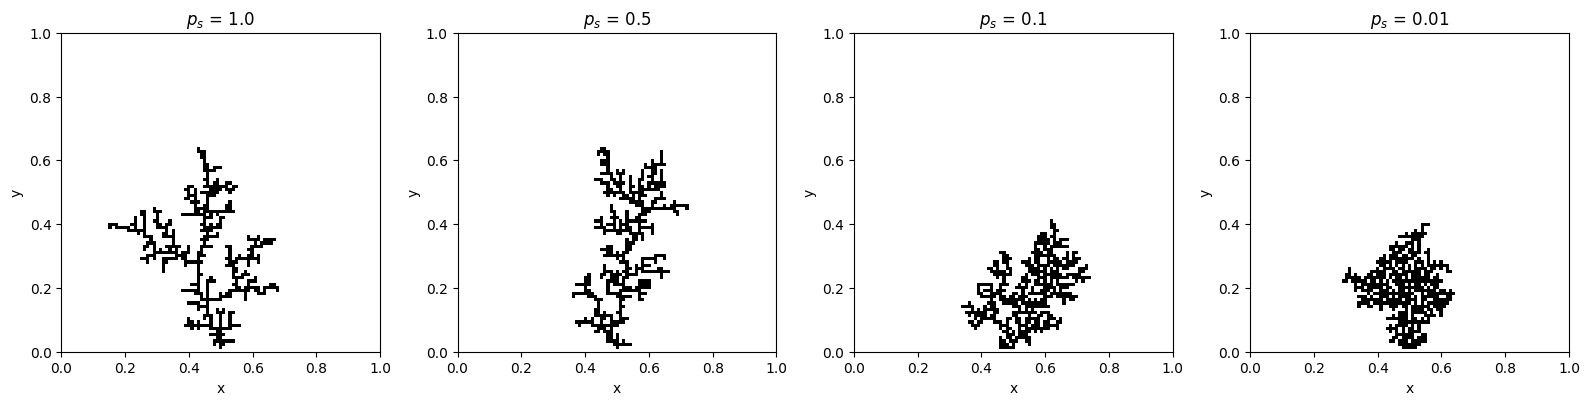

In [23]:
# --- Plot clusters for each ps value side by side ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for idx, (ps, mask) in enumerate(zip(ps_values, masks_ps)):
    plot_cluster(mask.T, title=f"$p_s$ = {ps}", ax=axes[idx])
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "mc_dla_ps_comparison.png"), dpi=300)
plt.show()